In [1]:
[View Interactive Plotly Graph on nbviewer] https://nbviewer.org/github/kamrankhanorakzai/Terrorism-Blast-Data-Analysis-in-pakistan-/blob/main/suicide_bomb_blast%20%28visiulization%29.ipynb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
pd.set_option("display.max_columns",None)
df=pd.read_pickle("cleaned_explosions.pkl")

df

,Date,Year,Islamic Date,Blast Day Type,Holiday Type,Time,City,Latitude,Longitude,Province,Location,Location Category,Location Sensitivity,Open/Closed Space,Influencing Event/Event,Target Type,Targeted Sect if any,Killed Min,Killed Max,Injured Min,Injured Max,No. of Suicide Blasts,Explosive Weight (max)(kg),Hospital Names,Temperature(C),Temperature(F),month_name,day_name,avg total killed,avg total injured
S#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1995-11-19,1995,25 Jumaada al-THaany 1416 A.H,Holiday,weekend,NaN,islamabad,33.718000,73.071800,capital,Egyptian Embassy,foreign,high,closed,NaN,foreigner,NaN,14,15,<NA>,60,2,0.0,NaN,15.835,60.503,November,Sunday,14.5,60.0
2,2000-11-06,2000,10 SHa`baan 1421 A.H,Working Day,NaN,NaN,karachi,24.991800,66.991100,sindh,office of Nawa-e-Waqt,office building,low,closed,NaN,media,NaN,<NA>,3,<NA>,3,1,0.0,NaN,23.770,74.786,November,Monday,3.0,3.0
3,2002-05-08,2002,25 safar 1423 A.H,Working Day,NaN,7:45 AM,karachi,24.991800,66.991100,sindh,Pakistan Navy bus Parked outside Five Star She...,hotel,medium,closed,NaN,foreigner,christian,13,15,20,40,1,2.5,[jinnah postgraduate medical center civil hos...,31.460,88.628,May,Wednesday,14.0,30.0
4,2002-06-14,2002,3 Raby` al-THaany 1423 A.H,Working Day,NaN,11:10:00 AM,karachi,24.991800,66.991100,sindh,US Consulate Civil Lines Area,foreign,high,closed,NaN,foreigner,christian,<NA>,12,<NA>,51,1,0.0,NaN,31.430,88.574,June,Friday,12.0,51.0
5,2003-07-04,2003,4 Jumaada al-awal 1424 A.H,Working Day,NaN,NaN,quetta,30.209500,67.018200,balochistan,Imambargah MeCongy Road Quetta,religious,medium,closed,during Friday prayer,religious,shiite,44,47,<NA>,65,1,0.0,"[cmh quettacivil hospital bol, medical complex]",33.120,91.616,July,Friday,45.5,65.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,2017-10-05,2017,13 MuHarram 1439 A.H,Working Day,NaN,NaN,quetta,28.571051,67.496895,balochistan,Fateh Pur Shrine in Jhal Magsi village,religious,high,open/closed,at the entrance of shrine,civilian,NaN,21,22,25,<NA>,1,0.0,"[larkana hospital, g, awah district headquarte...",27.800,81.000,October,Thursday,21.5,25.0
493,2017-10-19,2017,27 MuHarram 1439 A.H,Working Day,NaN,8:00 AM,quetta,NaN,NaN,balochistan,Sariab Mill area,highway,low,open,explosives-laden vehicle rammed into a securit...,police_rangers,NaN,7,7,22,22,1,0.0,NaN,26.000,79.000,October,Thursday,7.0,22.0
494,2017-11-09,2017,19 Safar 1439 A.H,Working Day,NaN,7:00 AM,quetta,30.221057,67.002524,balochistan,Quetta's Chaman Housing Scheme on airport road,police_rangers,low,open,AIG Hamid Shakil’s vehicle,police_rangers,NaN,2,2,8,8,1,15.0,"[combined military hospital (cmh), (quetta), c...",25.000,77.000,November,Thursday,2.0,8.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 496 entries, 1 to 496
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        496 non-null    datetime64[ns]
 1   Year                        496 non-null    int64         
 2   Islamic Date                342 non-null    object        
 3   Blast Day Type              486 non-null    category      
 4   Holiday Type                72 non-null     category      
 5   Time                        285 non-null    object        
 6   City                        496 non-null    category      
 7   Latitude                    493 non-null    float64       
 8   Longitude                   493 non-null    float64       
 9   Province                    496 non-null    category      
 10  Location                    493 non-null    object        
 11  Location Category           460 non-null    category      
 12 

# Univariate analysis

`categorical analysis` :count for each category number of suicide bomb blast


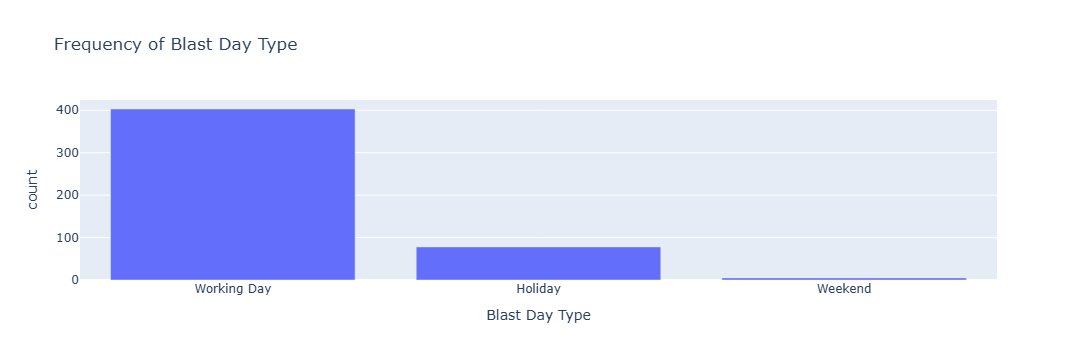

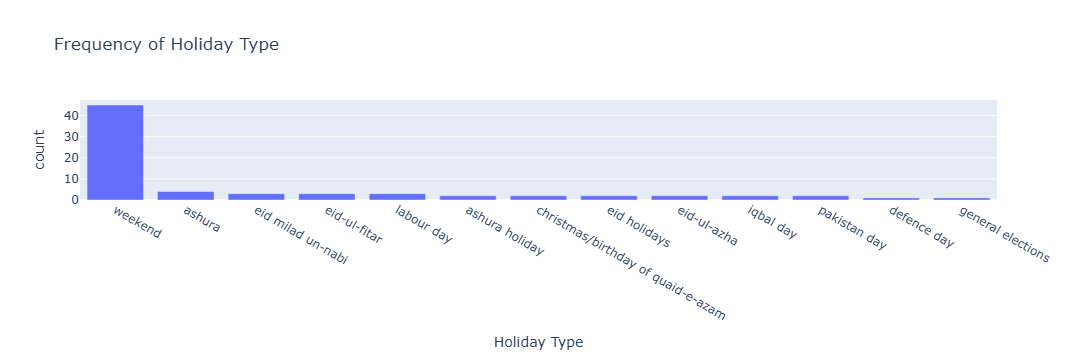

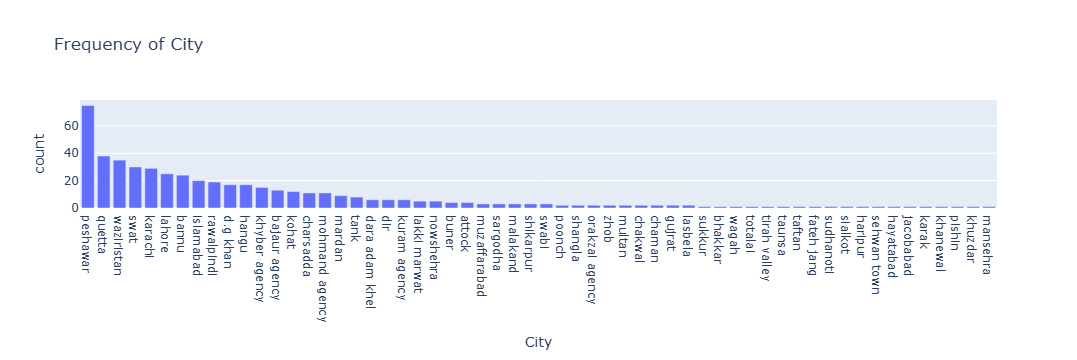

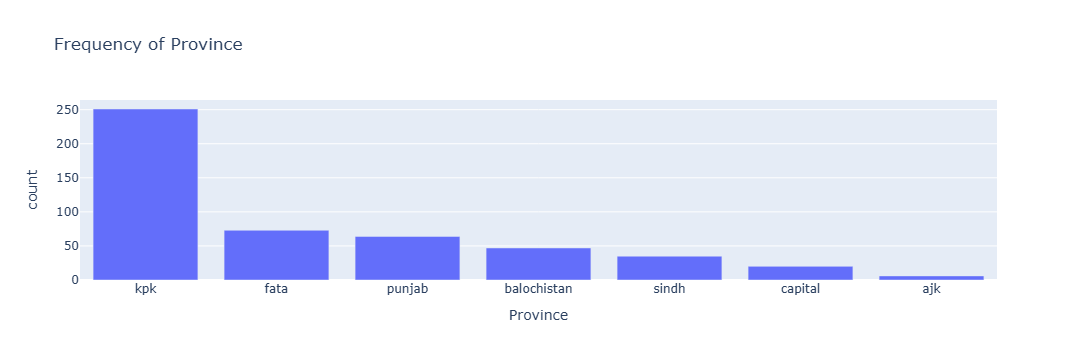

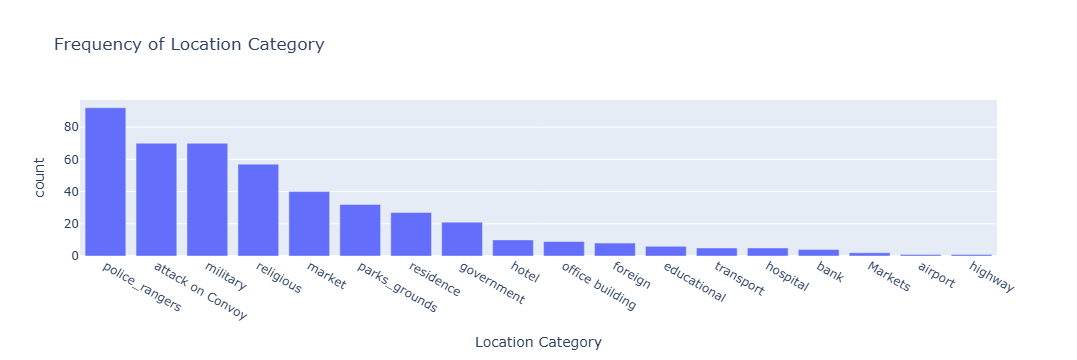

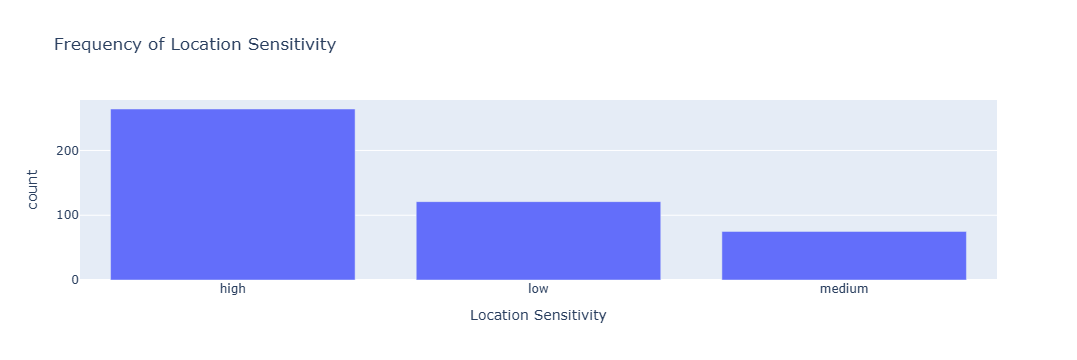

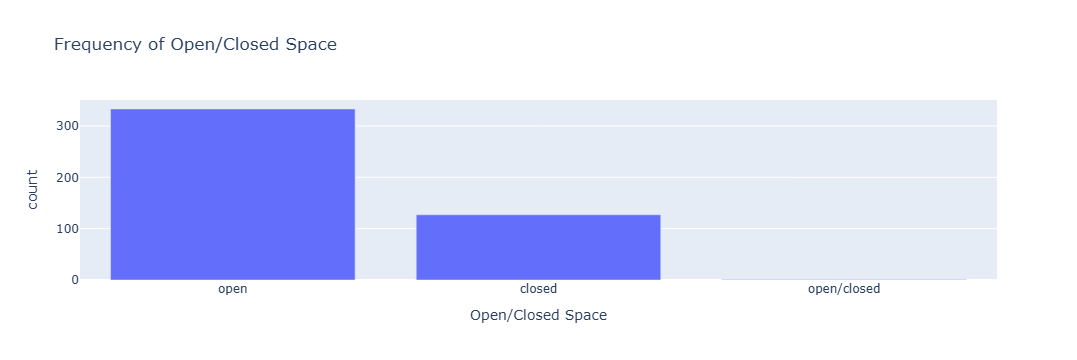

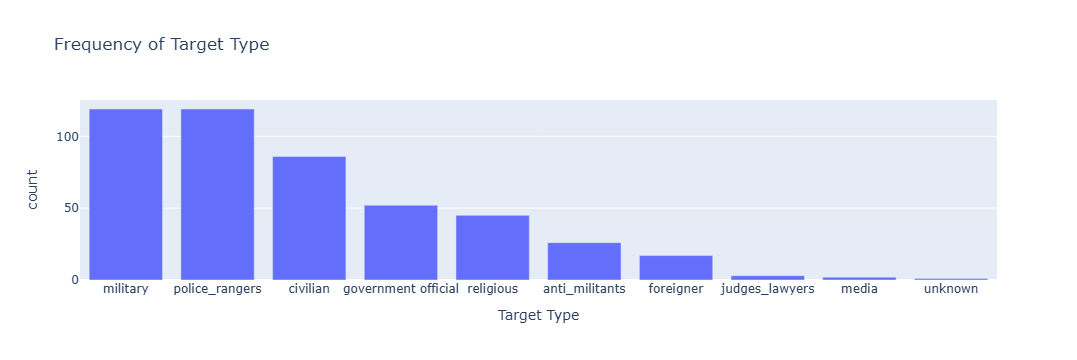

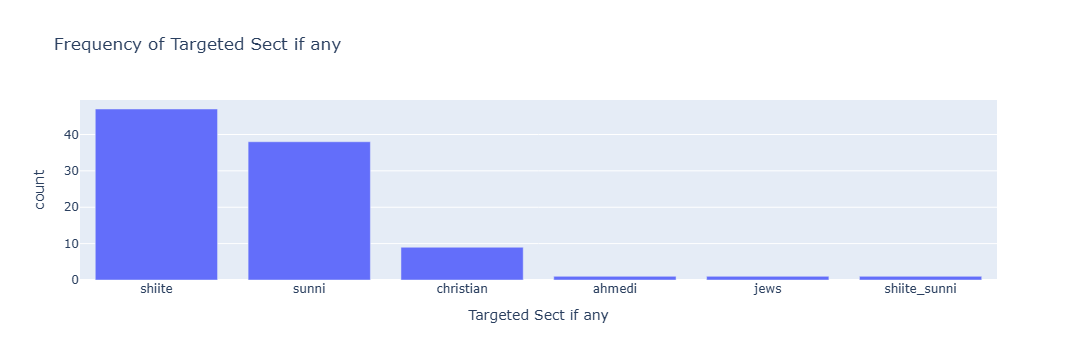

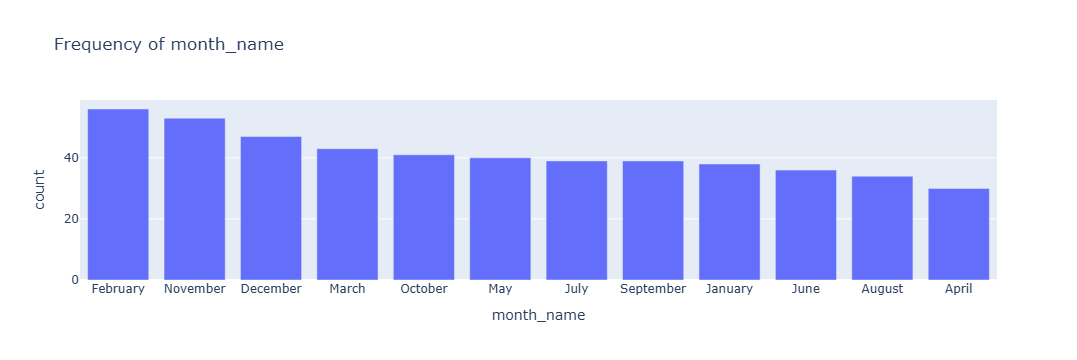

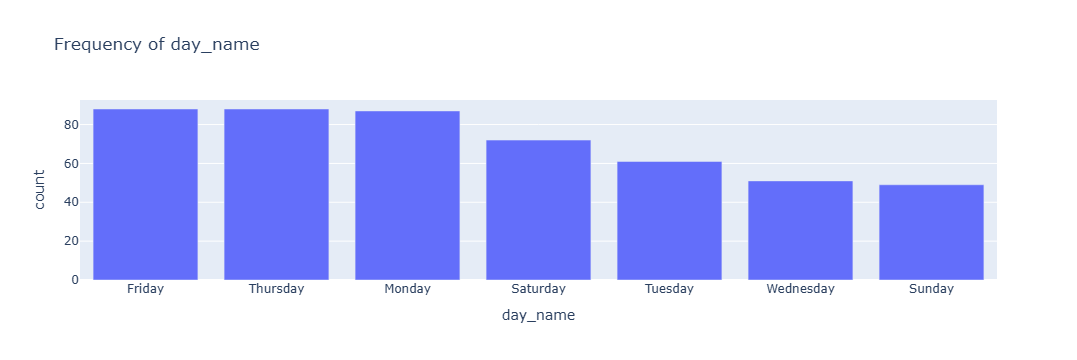

In [4]:
categorys=["Blast Day Type","Holiday Type","City","Province","Location Category","Location Sensitivity","Open/Closed Space","Target Type","Targeted Sect if any","month_name","day_name"]
for cat in categorys:
     fig=px.bar(df[cat].value_counts().reset_index(),x=cat,y="count",title=f"Frequency of {cat}")
     fig.show()


`univariate analysis for numeric columns`

`Descriptive statistics` → mean, median, std, min, max, quartiles.

In [5]:
num_cols = df.select_dtypes(include=["int64","float64","Int64","Float64"])


summary = num_cols.describe().T[["mean","std","min","25%","50%","75%","max"]]
summary

,mean,std,min,25%,50%,75%,max
Year,2010.3125,3.189174,1995.0,2008.0,2010.0,2013.0,2017.0
Latitude,32.614705,2.475917,24.879503,31.8238,33.5833,34.0043,35.3833
Longitude,70.995388,2.022427,62.35,70.1456,71.5249,72.3667,74.5729
Killed Min,14.725714,17.60093,0.0,3.0,8.0,20.0,125.0
Killed Max,15.20625,20.270436,0.0,3.0,8.0,18.25,148.0
Injured Min,31.39726,38.603842,0.0,7.0,20.0,40.0,320.0
Injured Max,39.45987,54.428383,0.0,8.0,23.0,50.0,550.0
No. of Suicide Blasts,1.115942,0.394989,1.0,1.0,1.0,1.0,4.0
Explosive Weight (max)(kg),38.11996,145.622812,0.0,0.0,0.0,8.0,1200.0
Temperature(C),21.111599,8.369068,-2.37,14.69,21.405,28.115,44.0


`Distribution visualization` → histogram, KDE (density), boxplot.

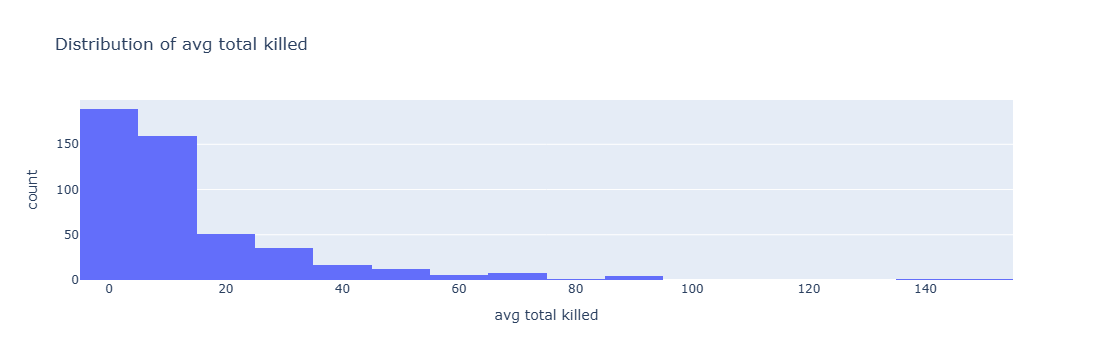

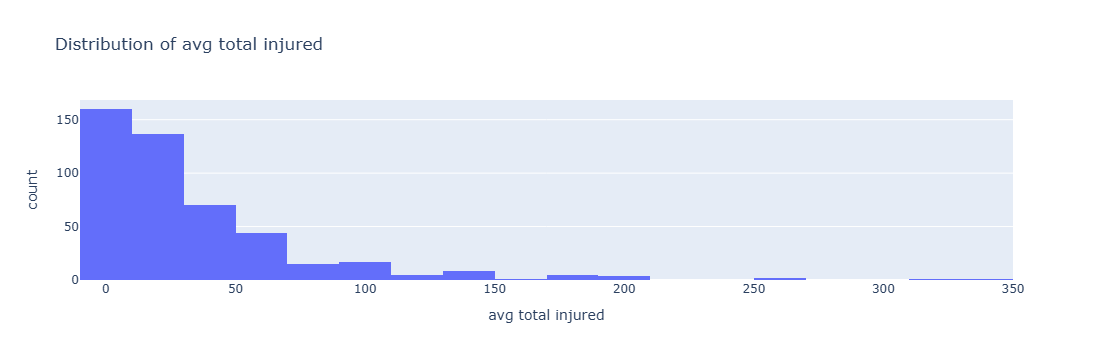

In [6]:

fig=px.histogram(df,x="avg total killed",nbins=20,title="Distribution of avg total killed")
fig.show()
fig=px.histogram(df,x="avg total injured",nbins=20,title="Distribution of avg total injured")
fig.show()

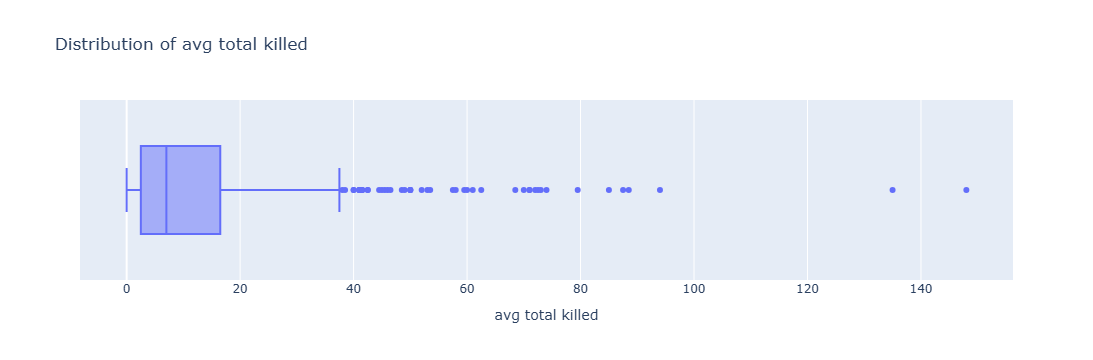

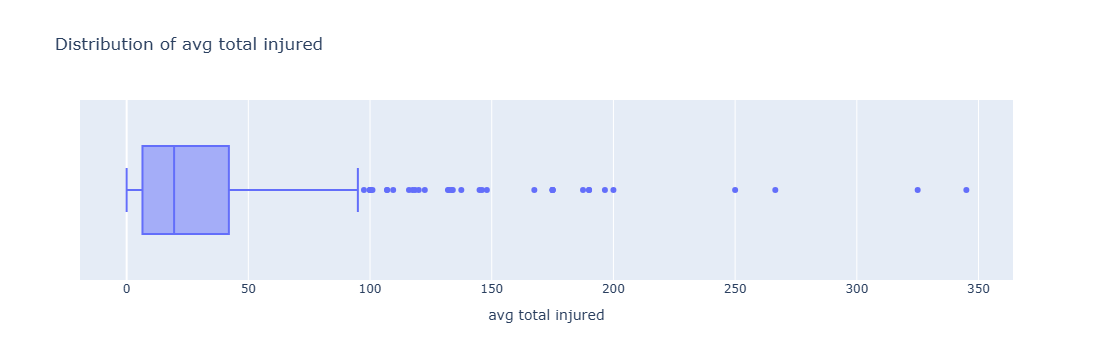

In [7]:
fig=px.box(df,x="avg total killed",title="Distribution of avg total killed")
fig.show()
fig=px.box(df,x="avg total injured",title="Distribution of avg total injured")
fig.show()

# Multivariate analysis

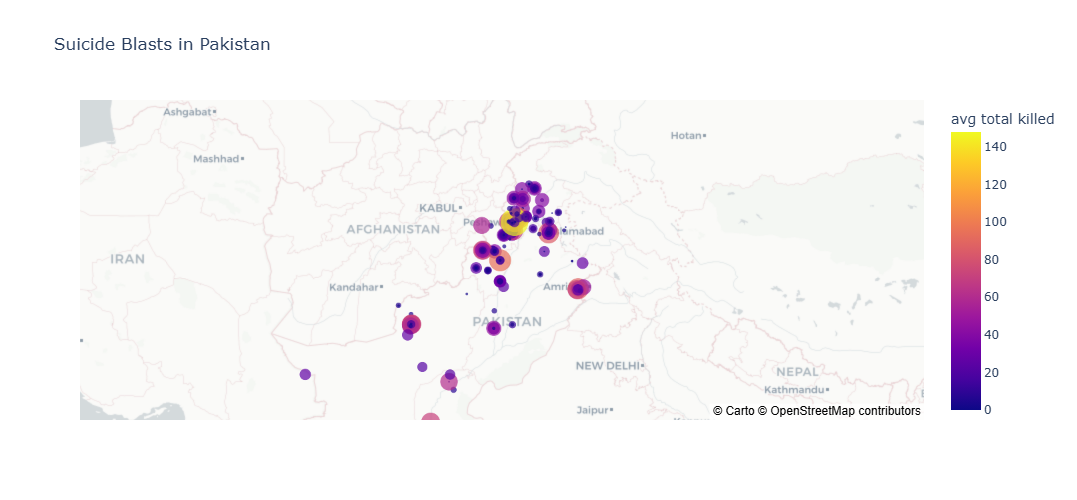

In [8]:
temp_df = df[df["Latitude"].notnull()].copy()
temp_df["avg total killed"]=temp_df["avg total killed"].fillna(temp_df["avg total killed"].mean())
fig = px.scatter_mapbox(
    temp_df,
    lat="Latitude",
    lon="Longitude",
    size="avg total killed",             # bubble size
    color="avg total killed",            # color scale
    hover_name="City",         # show city name on hover
        zoom=4,
    height=500,
    width=900,
    title="Suicide Blasts in Pakistan"
)

# Use free open-source map style
fig.update_layout(mapbox_style="carto-positron")

fig.show()


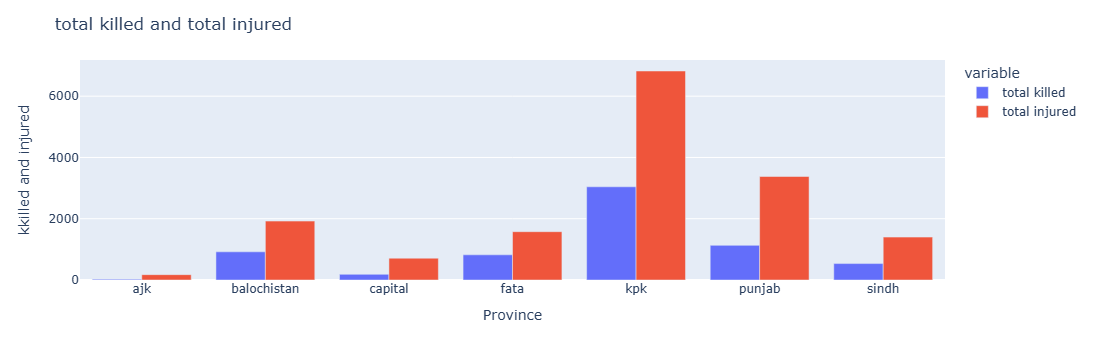

In [9]:
Province_df=df.groupby("Province",as_index=True).agg({"avg total killed":"sum","avg total injured":"sum"}).rename(columns={"avg total killed":"total killed","Province":"total blasts","avg total injured":"total injured"})
fig=px.bar(Province_df,x=Province_df.index,y=['total killed',"total injured"],barmode="group",labels={"value":"kkilled and injured"})
fig.update_layout(title="total killed and total injured")
fig.show()

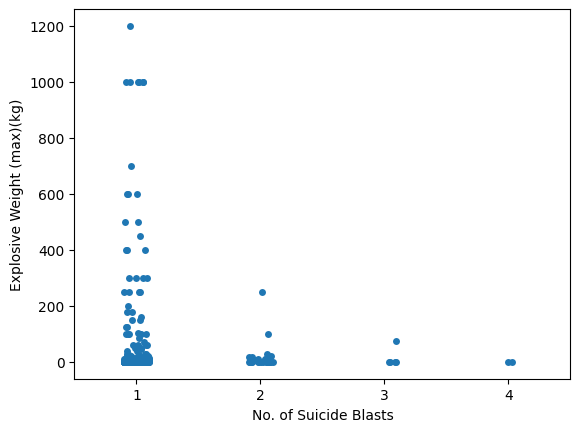

In [10]:
temp_df=df[["No. of Suicide Blasts","Explosive Weight (max)(kg)","avg total killed","avg total injured"]].copy()
temp_df["No. of Suicide Blasts"]=temp_df["No. of Suicide Blasts"].fillna(1)
temp_df["avg total injured"]=temp_df["avg total injured"].fillna(temp_df['avg total injured'].mean())
temp_df["avg total killed"]=temp_df["avg total killed"].fillna(temp_df["avg total killed"].mean()).astype("float")
fig=sns.stripplot(temp_df,x="No. of Suicide Blasts",y="Explosive Weight (max)(kg)",jitter=True)
plt.show()


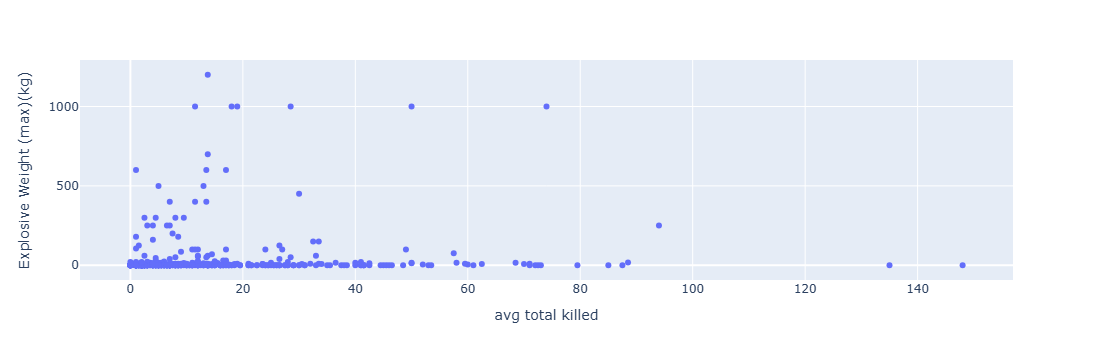

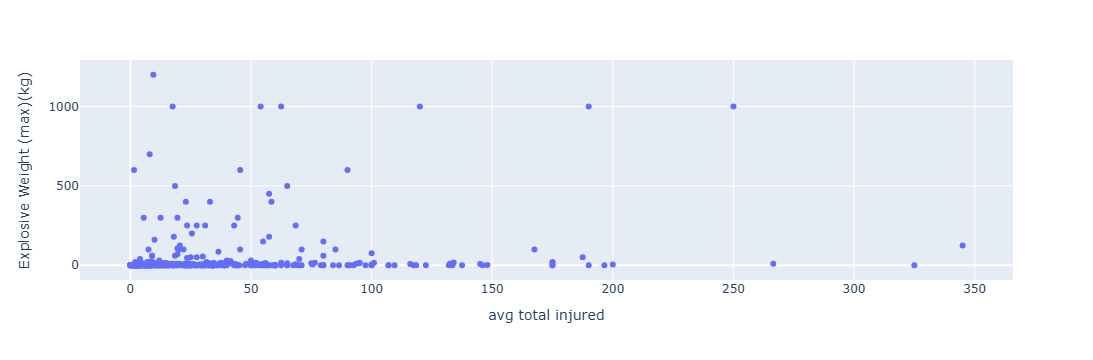

In [11]:
fig=px.scatter(temp_df,x="avg total killed",y="Explosive Weight (max)(kg)")
fig.show()
fig=px.scatter(temp_df,x="avg total injured",y="Explosive Weight (max)(kg)")
fig.show()

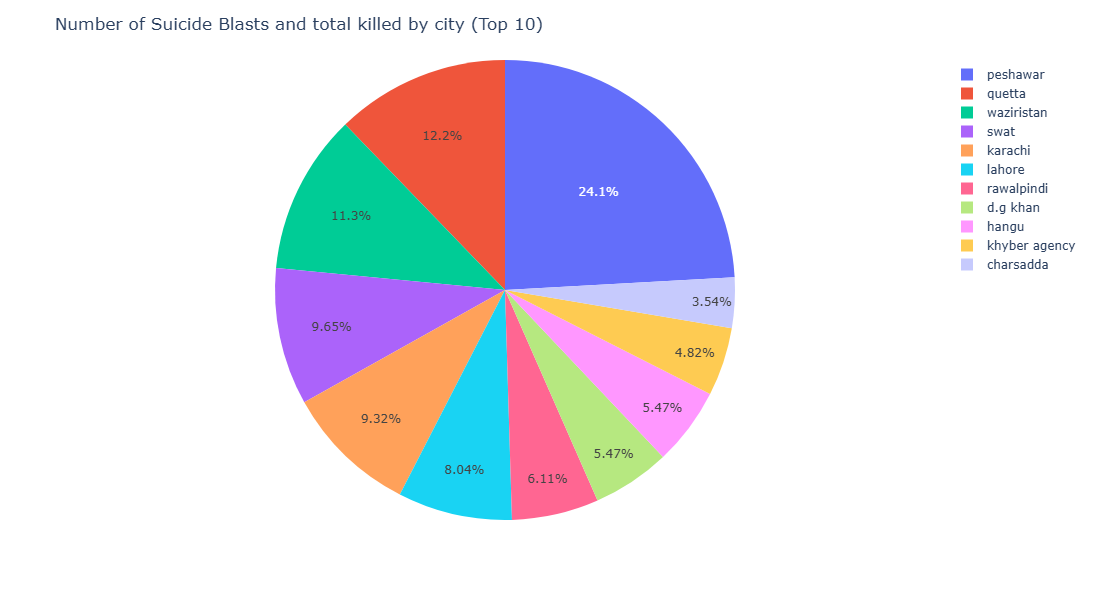

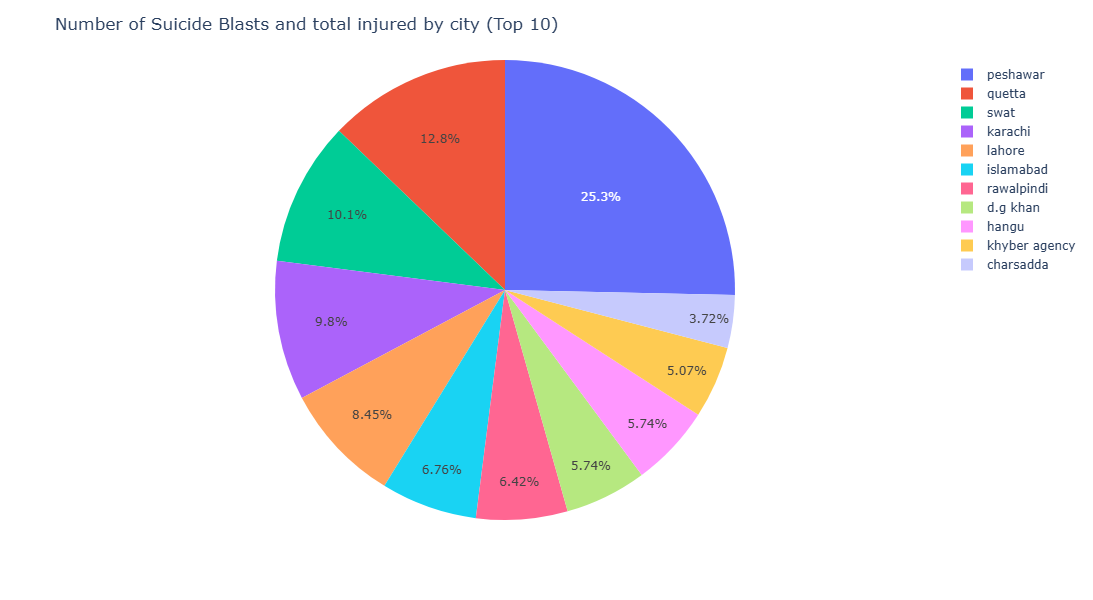

In [12]:
city_df=df.groupby("City",as_index=True).agg(total_blasts=("City","count"),total_kill=("avg total killed","sum")).sort_values(by="total_kill",ascending=False).iloc[0:11]
fig=px.pie(city_df,values="total_blasts",names=city_df.index,width=600,height=600,hover_data=["total_kill"])
fig.update_layout(title="Number of Suicide Blasts and total killed by city (Top 10)")
fig.show()


city_df=df.groupby("City",as_index=True).agg(total_blasts=("City","count"),total_injured=("avg total injured","sum")).sort_values(by="total_injured",ascending=False).iloc[0:11]
fig=px.pie(city_df,values="total_blasts",names=city_df.index,width=600,height=600,hover_data=["total_injured"])
fig.update_layout(title="Number of Suicide Blasts and total injured by city (Top 10)")
fig.show()

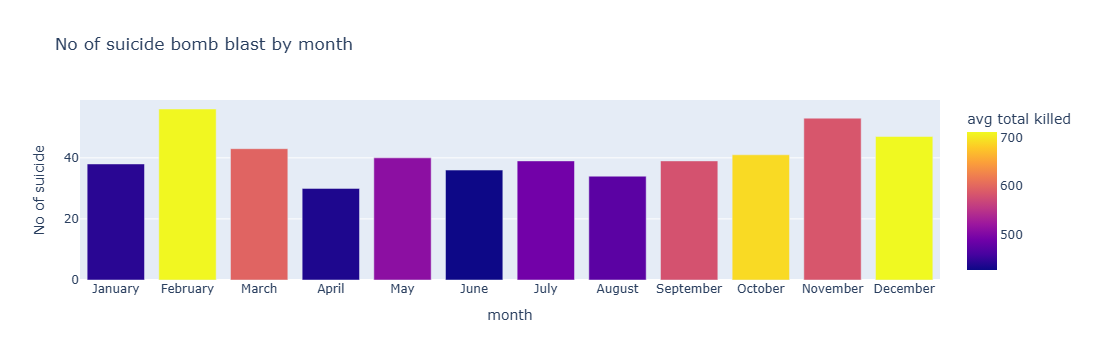

In [13]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
month=df.groupby("month_name").agg({"month_name":"count","avg total killed":"sum"}).reindex(month_order)
fig=px.bar(data_frame=month,x=month.index,color="avg total killed",y="month_name",title="No of suicide bomb blast by month",labels={"month_name":"No of suicide","index":"month"})
fig.show()


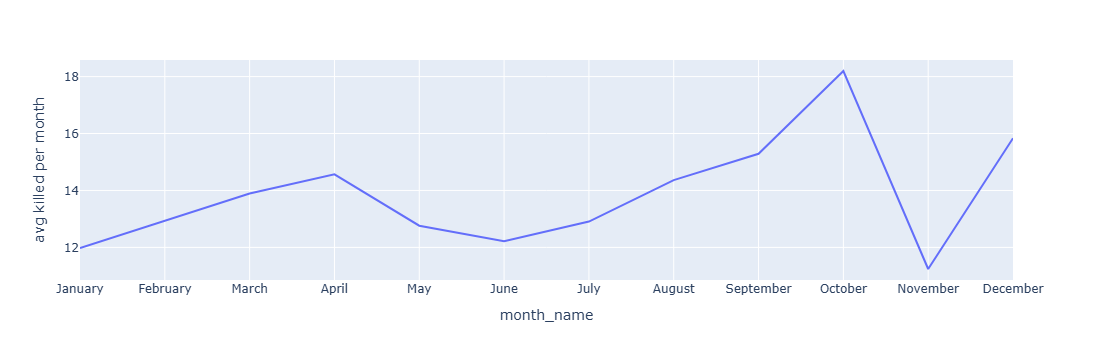

In [22]:
avg_kill_month=df.groupby("month_name")["avg total killed"].mean().reindex(month_order).reset_index()
fig=px.line(data_frame=avg_kill_month,x="month_name",y="avg total killed",labels={"avg total killed":"avg killed per month"})
fig.show()


frequency count of bomb blast and average kill by day

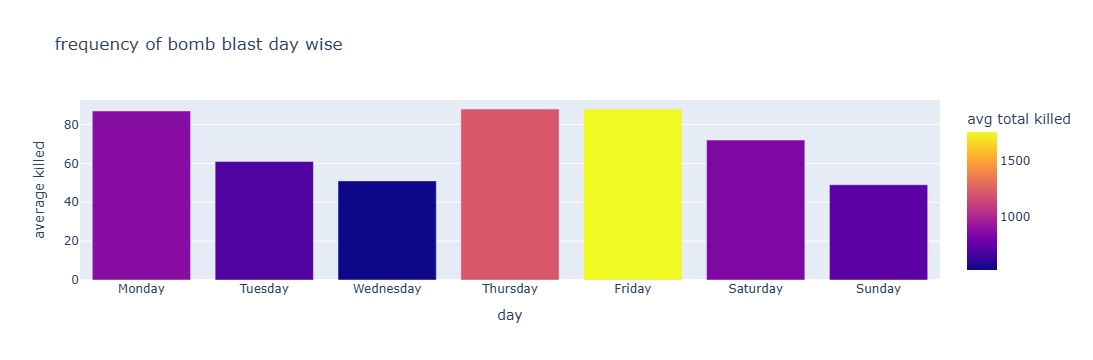

In [15]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day=df.groupby("day_name",observed=True).agg({"day_name":"count","avg total killed":"sum"}).reindex(day_order)
fig=px.bar(day,x=day.index,y="day_name",color="avg total killed",title="frequency of bomb blast day wise",labels={"day_name":"average killed","index":"day"})
fig.show()

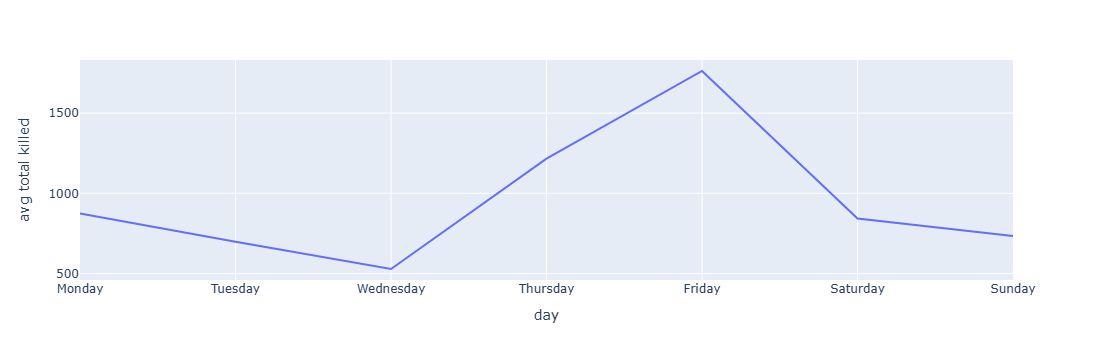

In [16]:
fig=px.line(day,x=day.index,y="avg total killed",labels={"day_name":"average killed","index":"day"})
fig.show()

Average total killed by Target type 

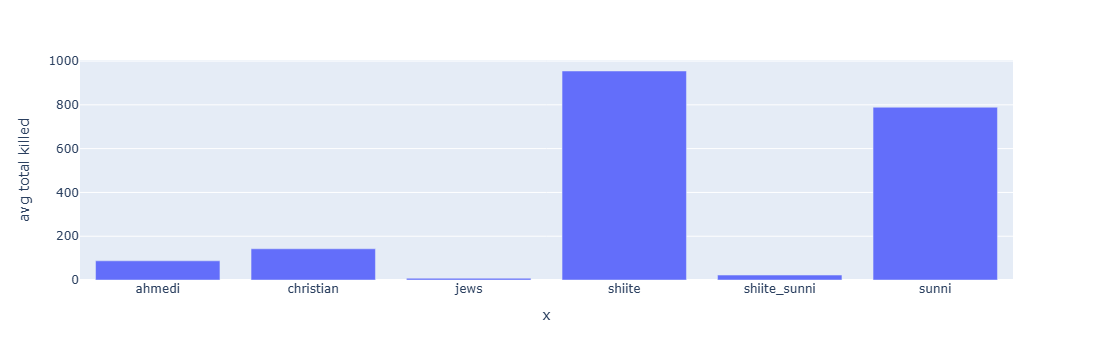

In [17]:
target_sect=df.groupby("Targeted Sect if any")["avg total killed"].sum()
fig=px.bar(target_sect,x=target_sect.index,y="avg total killed")
fig.show()

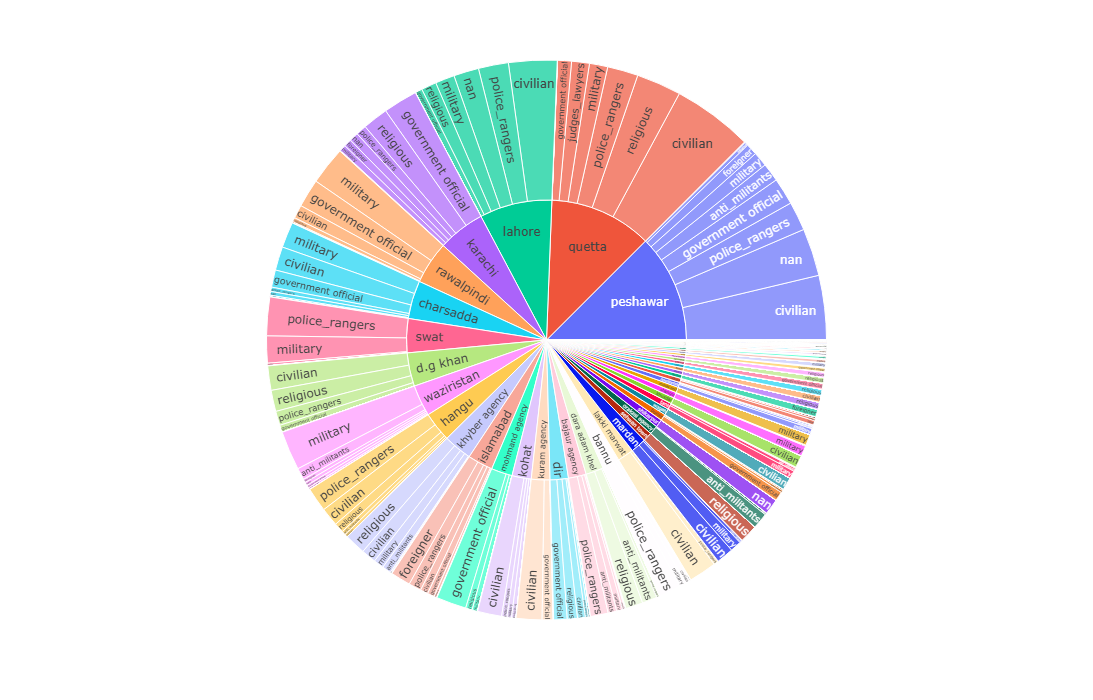

In [18]:
# fig=px.sunburst(df)
temp_df=df[["City","Target Type","avg total killed"]].copy()
temp_df["avg total killed"]=temp_df["avg total killed"].fillna(temp_df["avg total killed"].mean())
temp_df["Target Type"]=temp_df["Target Type"].astype("str").fillna("undefine")

fig=px.sunburst(temp_df,path=["City","Target Type"],values="avg total killed",height=700)
fig.show()

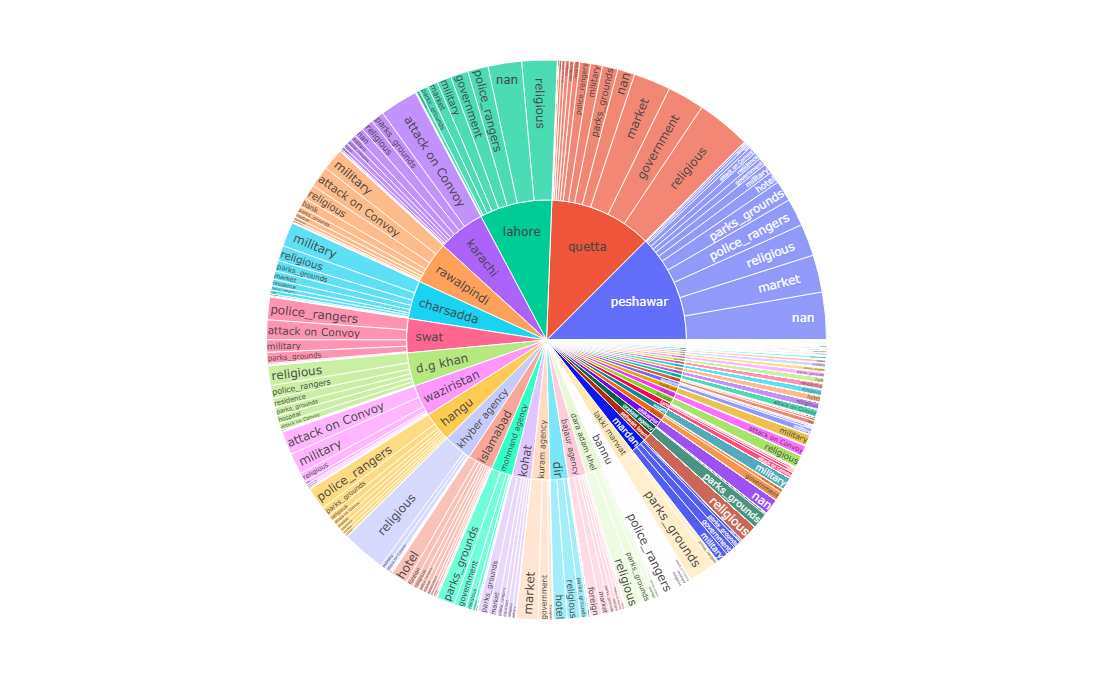

In [19]:
temp_df=df[["City","Location Category","avg total killed"]].copy()
temp_df["avg total killed"]=temp_df["avg total killed"].fillna(temp_df["avg total killed"].mean())
temp_df["Location Category"]=temp_df["Location Category"].astype("str").fillna("undefine")
fig=px.sunburst(temp_df,path=["City","Location Category"],values="avg total killed",height=700)
fig.show()

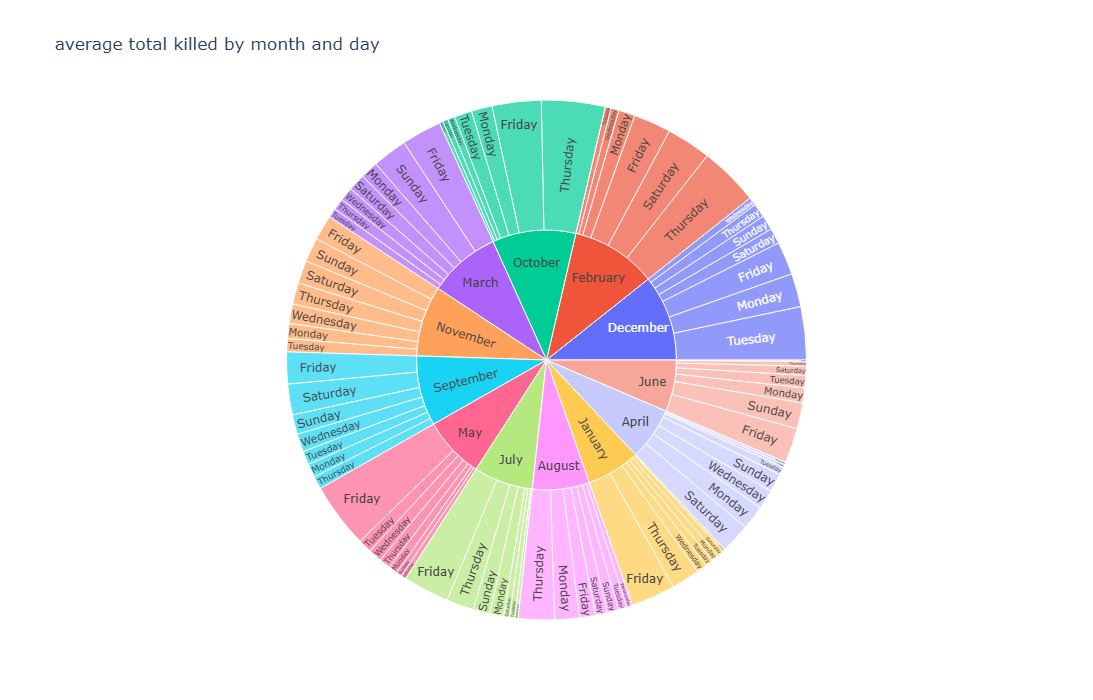

In [20]:
fig=px.sunburst(df,path=["month_name","day_name"],values="avg total killed",height=700,title="average total killed by month and day")
fig.show()

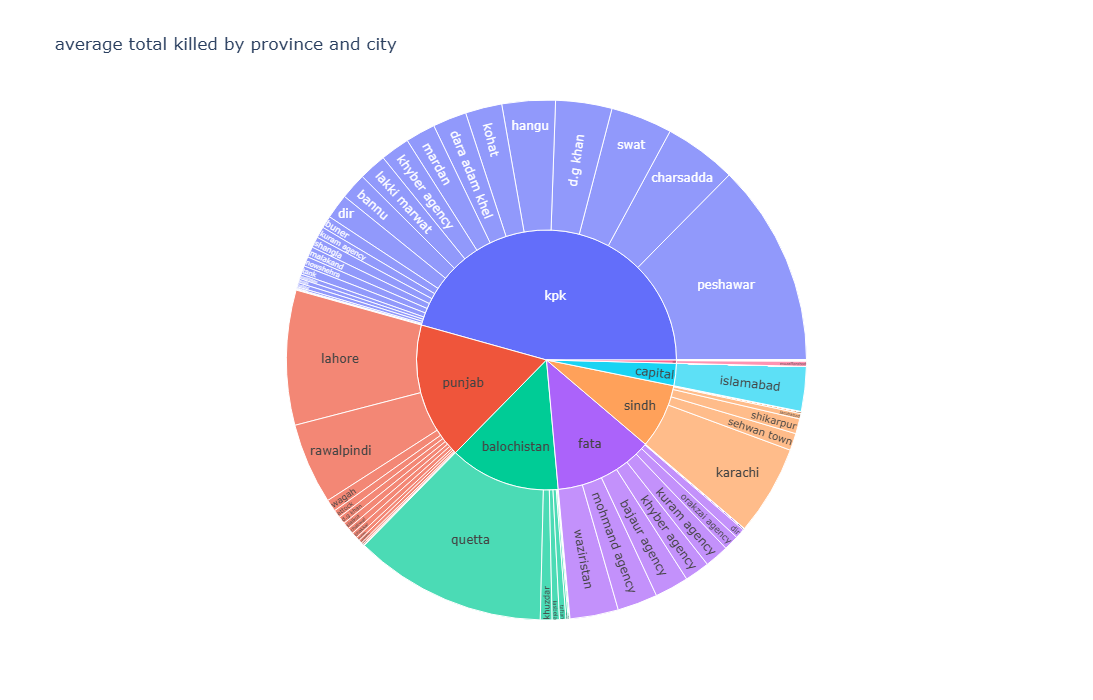

In [21]:

fig=px.sunburst(df,path=["Province","City"],values="avg total killed",height=700,title="average total killed by province and city")
fig.show()
